## What happens in this notebook (overview)

This notebook runs the **final compound-level GC–MS workflow** :

- **Loads compound identification outputs** (e.g., NIST/CSV exports) for both *samples* and *blanks/QCs*.
- **Cleans and standardizes names/metadata** so compounds are consistent across files (aliases and formatting differences handled).
- **Removes contamination/background signals** by comparing detections in blanks/env/QC versus samples within a retention-time tolerance.
- **Matches identified compounds to the corrected peak tables** (using RT and, where applicable, m/z tolerances) to link IDs to quantitative intensities.
- **Builds compound intensity matrices** (wide + long formats) at the variety/sample level for downstream statistics and modeling.
- **Annotates compounds** with curated potato-aroma information, sensory descriptions, and chemical families.
- **Links compounds to the sensory panel data** by merging on shared sample/variety identifiers, enabling direct comparison between chemical profiles and sensory traits.
- **Generates summaries and plots** (e.g., filtering impact, family distributions, top-compound heatmaps, PCA/clustering/outlier views) for reporting.

Implementation-wise, these steps are executed using the internal module **`compound_analysis.py`** to keep results consistent and reproducible across runs.


In [0]:
%pip uninstall -y matplotlib
%pip install matplotlib==3.8.4

Found existing installation: matplotlib 3.10.0
Not uninstalling matplotlib at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-b64eb71b-68fb-4f9f-971e-54c68048f9f1
Can't uninstall 'matplotlib'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 97.5 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Not uninstalling matplotlib at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-b64eb71b-68fb-4f9f-971e-54c68048f9f1
    Can't uninstall 'matplotlib'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:

import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse
from difflib import get_close_matches
from sklearn.impute import KNNImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
import os, importlib.util
!pip install openpyxl
import yaml
import importlib.util
import compound_analysis 
from compound_analysis import (
    assign_aroma_descriptions_and_families,
    plot_aroma_family_distribution
)

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Data Aggregation: Combining Sample and Nist library Compound Files

In [0]:

import compound_analysis as cam
# =====================================================
# 0) LOAD CONFIG
# =====================================================
CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

data_paths = config["data_paths"]

base_dir = data_paths["base_compound_dir_american"]
output_path = data_paths["output_path_american"]

sample_files = data_paths["sample_files_american"]
blank_files = data_paths["blank_files_american"]
env_files = data_paths.get("env_files_american", [])

print(f"Samples: {len(sample_files)} | blanks: {len(blank_files)} | env: {len(env_files)}")

# -----------------------------------------------------
# SAFETY CHECK: no DBFS paths for pandas
# -----------------------------------------------------
assert not output_path.startswith("/dbfs"), f" pandas cannot write to DBFS: {output_path}"



# =====================================================
# 2) COMBINE SAMPLE + BLANK (MODULE)
# =====================================================
combined_df = cam.combine_compound_data(
    base_dir=base_dir,
    sample_files=sample_files,
    blank_files=blank_files,
    output_path=output_path
)

# =====================================================
# 3) STANDARDIZE COLUMNS
# =====================================================
rename_map = {
    "Component": "Component RT",
    "Compound": "Compound Name",
    "Name": "Compound Name"
}

combined_df = combined_df.rename(
    columns={k: v for k, v in rename_map.items() if k in combined_df.columns}
)

combined_df["FileType"] = combined_df["FileType"].fillna("sample")

# =====================================================
# 4) ADD ENV FILES (AS-IS)
# =====================================================
env_dfs = []

for env_path in env_files:
    assert os.path.exists(env_path), f" Env file not found: {env_path}"

    env_df = pd.read_csv(env_path)
    env_df = env_df.rename(
        columns={k: v for k, v in rename_map.items() if k in env_df.columns}
    )

    env_df["FileType"] = "env"
    env_df["FileName"] = os.path.basename(env_path)
    env_df["FilePath"] = env_path

    env_dfs.append(env_df)

if env_dfs:
    combined_df = pd.concat([combined_df] + env_dfs, ignore_index=True)

# =====================================================
# 5) SAVE FINAL FILE (SAFE)
# =====================================================
out_dir = os.path.dirname(output_path)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

combined_df.to_csv(output_path, index=False)

# =====================================================
# 6) FINAL CHECK
# =====================================================
print("\nFinal FileType counts:")
print(combined_df["FileType"].value_counts())

print("\nSaved to:")
print(output_path)


Samples: 57 | blanks: 1 | env: 1

Combined file saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american/combined.csv
FileType
sample    4087
blank       61
Name: count, dtype: int64
   Component RT  ...                                           FilePath
0      2.047533  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
1      2.201867  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
2      2.343311  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
3      2.619867  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
4      2.954250  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...

[5 rows x 9 columns]

Final FileType counts:
FileType
sample    4087
blank       61
env         53
Name: count, dtype: int64

Saved to:
/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american/combined.csv


#  Contamination filtering

Sample compounds before filtering: 4087
Sample compounds after filtering: 2870
Removed 1217 sample peaks (ΔRT ≤ 0.4)
      Component RT  ...                                           FilePath
3056      2.025117  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
1864      2.031417  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
1345      2.031517  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
2492      2.031600  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
1490      2.034683  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
...            ...  ...                                                ...
3536     23.420100  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
728      23.423200  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
799      23.423367  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
3055     23.429417  ...  /Volumes/bmqg/default_bronze/fatemeh/data/Amer...
215      23.436033  ...  /Volumes/bmqg/default_bronze/fate

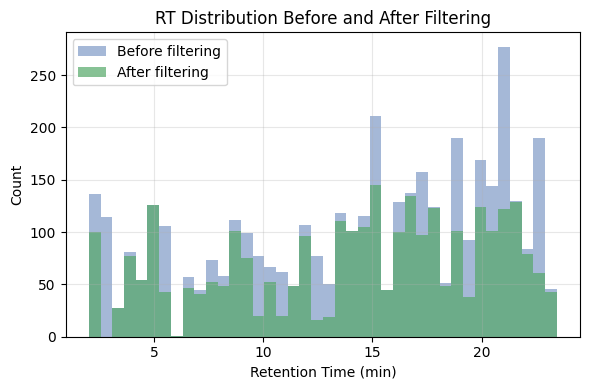

 RT distribution plot generated successfully.


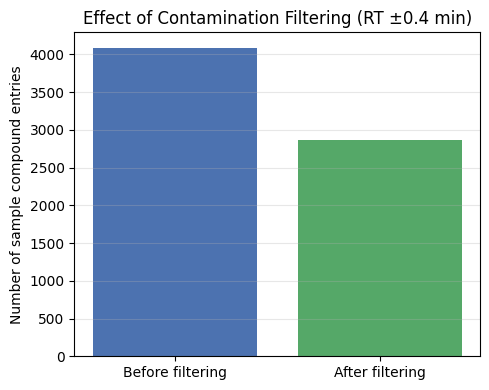

 Filtering effect plot generated successfully. (Before: 4087, After: 2870)


In [0]:

real_compounds = cam.filter_real_compounds(combined_df, rt_tolerance=0.4)
print(real_compounds)
cam.plot_rt_distribution(combined_df, real_compounds)
cam.plot_filtering_effect(combined_df, real_compounds, rt_tolerance=0.4)


# Checking the presence of known potato aroma compounds

In [0]:
import os
import importlib
import pandas as pd
import compound_analysis as cam

importlib.reload(cam)

# ------------------------------------------------------------
# 1) PATHS FROM CONFIG
# ------------------------------------------------------------
sample_cfg = config["sample"]
paths_cfg = config["paths"]

prepared_sample = sample_cfg["output_file_american"]
out_dir = paths_cfg["save_dir"]
master_table_path = paths_cfg["master_table_american"]
aroma_matrix_path = paths_cfg["aroma_matrix_american"]   

assert os.path.exists(prepared_sample), f"prepared sample not found: {prepared_sample}"
assert os.path.exists(master_table_path), f"master table not found: {master_table_path}"

os.makedirs(out_dir, exist_ok=True)
os.makedirs(os.path.dirname(aroma_matrix_path), exist_ok=True) 

# ------------------------------------------------------------
# 2) PREPARED SAMPLE CHECK
# ------------------------------------------------------------
samples_df = pd.read_csv(prepared_sample)
print("prepared_sample:", prepared_sample)
print("samples columns:", list(samples_df.columns)[:10])
display(samples_df.head())

# ------------------------------------------------------------
# 3) LOAD MASTER TABLE + EXTRACT TRUE VARIETY
# ------------------------------------------------------------
master_table = pd.read_excel(master_table_path, engine="openpyxl")
master_table.columns = master_table.columns.astype(str).str.strip()

master_table = master_table.rename(columns={
    "filename": "Filename",
    "sample": "Sample",
})

master_table["Filename"] = master_table["Filename"].astype(str).str.strip()
master_table["Sample"] = master_table["Sample"].astype(str).str.strip()

def extract_variety(sample_value):
    s = str(sample_value).strip()
    if ";" in s:
        return s.split(";")[-1].strip()
    return s

master_table["Variety_clean"] = master_table["Sample"].apply(extract_variety)

print(master_table[["Filename", "Sample", "Variety_clean"]].head(20))

# ------------------------------------------------------------
# 4) INPUT DATAFRAME
# ------------------------------------------------------------
real_compounds = combined_df.copy()

rename_map = {
    "Component": "Component RT",
    "Compound": "Compound Name",
    "Name": "Compound Name",
}

real_compounds = real_compounds.rename(
    columns={k: v for k, v in rename_map.items() if k in real_compounds.columns}
)

if "FileType" not in real_compounds.columns:
    real_compounds["FileType"] = "sample"

print("Combined rows:", len(real_compounds))

# ------------------------------------------------------------
# 5) MATCH POTATO AROMAS
# ------------------------------------------------------------
res = cam.match_potato_aromas_strict_from_notebook(
    combined_df=real_compounds,
    samples_filtered_path=prepared_sample,
    out_dir=out_dir,
    paths=config["paths"],
    rt_tol=0.4,
    mz_tol=0.5
)

print("res keys:", list(res.keys()))

matched = res["matched_per_variety"].copy()

# ------------------------------------------------------------
# 6) REPLACE Variety WITH TRUE VARIETY NAME
# ------------------------------------------------------------
matched["Variety_raw"] = matched["Variety"].astype(str).str.strip()

matched["Filename_key"] = matched["Variety_raw"].str.replace(
    r"^s\d+\s+",
    "",
    regex=True
).str.strip()

filename_to_variety = (
    master_table.dropna(subset=["Filename", "Variety_clean"])
    .drop_duplicates(subset=["Filename"])
    .set_index("Filename")["Variety_clean"]
    .to_dict()
)

matched["Variety_from_master"] = matched["Filename_key"].map(filename_to_variety)
matched["Variety"] = matched["Variety_from_master"].fillna(matched["Variety_raw"])

print("Unmapped rows:", matched["Variety_from_master"].isna().sum())

display(
    matched[
        ["Variety_raw", "Filename_key", "Variety", "Compound Name", "tR_best", "m/z", "peak_Intensity"]
    ].head(20)
)

# ------------------------------------------------------------
# 7) BUILD + CLEAN AROMA MATRIX
# ------------------------------------------------------------
aroma_matrix = res["aroma_matrix"].copy()

aroma_matrix["Variety_raw"] = aroma_matrix["Variety"].astype(str).str.strip()

aroma_matrix["Filename_key"] = aroma_matrix["Variety_raw"].str.replace(
    r"^s\d+\s+",
    "",
    regex=True
).str.strip()

aroma_matrix["Variety_from_master"] = aroma_matrix["Filename_key"].map(filename_to_variety)
aroma_matrix["Variety"] = aroma_matrix["Variety_from_master"].fillna(aroma_matrix["Variety_raw"])

aroma_matrix = aroma_matrix.drop(columns=["Variety_raw", "Filename_key", "Variety_from_master"])

print("Aroma matrix shape:", aroma_matrix.shape)
display(aroma_matrix.head())

# ------------------------------------------------------------
# 8) SAVE AS aroma_matrix_newharvested
# ------------------------------------------------------------
aroma_matrix.to_csv(aroma_matrix_path, index=False)

# optional: keep in result dict too
res["aroma_matrix_newharvested"] = aroma_matrix

print(f"Saved aroma matrix to: {aroma_matrix_path}")

prepared_sample: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american/df_corrected.csv
samples columns: ['Peak', 'tR_best', 'm/z', 's21 KW25_1_B1_D1_T1', 's43 KW25_2_B1_D1_T1', 's64 KW25_3_B1_D1_T1', 's86 KW25_4_B1_D1_T1', 's104 KW25_5_B1_D1_T1', 's106 KW25_6_B1_D1_T1', 's108 KW25_7_B1_D1_T1']


Peak,tR_best,m/z,s21 KW25_1_B1_D1_T1,s43 KW25_2_B1_D1_T1,s64 KW25_3_B1_D1_T1,s86 KW25_4_B1_D1_T1,s104 KW25_5_B1_D1_T1,s106 KW25_6_B1_D1_T1,s108 KW25_7_B1_D1_T1,s110 KW25_8_B1_D1_T1,s112 KW25_9_B1_D1_T1,s1 KW25_10_B1_D1_T1,s3 KW25_11_B1_D1_T1,s5 KW25_12_B1_D1_T1,s7 KW25_13_B1_D2_T1,s9 KW25_14_B1_D2_T1,s11 KW25_15_B1_D2_T1,s13 KW25_16_B1_D2_T1,s15 KW25_17_B1_D2_T1,s17 KW25_18_B1_D2_T1,s19 KW25_19_B1_D2_T1,s23 KW25_20_B1_D2_T1,s25 KW25_21_B1_D2_T1,s27 KW25_22_B1_D2_T1,s29 KW25_23_B1_D2_T1,s31 KW25_24_B1_D2_T1,s33 KW25_25_B1_D3_T1,s35 KW25_26_B1_D3_T1,s37 KW25_27_B1_D3_T1,s39 KW25_28_B1_D3_T1,s41 KW25_29_B1_D3_T1,s45 KW25_30_B1_D3_T1,s47 KW25_31_B1_D3_T1,s49 KW25_32_B1_D3_T1,s51 KW25_33_B1_D3_T1,s53 KW25_34_B1_D3_T1,s55 KW25_35_B1_D3_T1,s57 KW25_36_B1_D3_T1,s60 KW25_38_B1_D4_T1,s62 KW25_39_B1_D4_T1,s66 KW25_40_B1_D4_T1,s68 KW25_41_B1_D4_T1,s70 KW25_42_B1_D4_T1,s72 KW25_43_B1_D4_T1,s74 KW25_44_B1_D4_T1,s76 KW25_45_B1_D4_T1,s78 KW25_46_B1_D4_T1,s80 KW25_47_B1_D4_T1,s82 KW25_48_B1_D4_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1.1,s84 KW25_49_B1_D5_T1.2,s84 KW25_49_B1_D5_T1.3,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1.1,s88 KW25_50_B1_D5_T1.2,s88 KW25_50_B1_D5_T1.3,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1.1,s90 KW25_51_B1_D5_T1.2,s90 KW25_51_B1_D5_T1.3,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1.1,s92 KW25_52_B1_D5_T1.2,s92 KW25_52_B1_D5_T1.3,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1.1,s94 KW25_53_B1_D5_T1.2,s94 KW25_53_B1_D5_T1.3,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1.1,s96 KW25_54_B1_D5_T1.2,s96 KW25_54_B1_D5_T1.3,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1.1,s98 KW25_55_B1_D5_T1.2,s98 KW25_55_B1_D5_T1.3,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1.1,s100 KW25_56_B1_D5_T1.2,s100 KW25_56_B1_D5_T1.3,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1.1,s102 KW25_57_B1_D5_T1.2,s102 KW25_57_B1_D5_T1.3,s84 KW25_49_B1_D5_T1.4,s84 KW25_49_B1_D5_T1.5,s84 KW25_49_B1_D5_T1.6,s84 KW25_49_B1_D5_T1.7,s88 KW25_50_B1_D5_T1.4,s88 KW25_50_B1_D5_T1.5,s88 KW25_50_B1_D5_T1.6,s88 KW25_50_B1_D5_T1.7,s90 KW25_51_B1_D5_T1.4,s90 KW25_51_B1_D5_T1.5,s90 KW25_51_B1_D5_T1.6,s90 KW25_51_B1_D5_T1.7,s92 KW25_52_B1_D5_T1.4,s92 KW25_52_B1_D5_T1.5,s92 KW25_52_B1_D5_T1.6,s92 KW25_52_B1_D5_T1.7,s94 KW25_53_B1_D5_T1.4,s94 KW25_53_B1_D5_T1.5,s94 KW25_53_B1_D5_T1.6,s94 KW25_53_B1_D5_T1.7,s96 KW25_54_B1_D5_T1.4,s96 KW25_54_B1_D5_T1.5,s96 KW25_54_B1_D5_T1.6,s96 KW25_54_B1_D5_T1.7,s98 KW25_55_B1_D5_T1.4,s98 KW25_55_B1_D5_T1.5,s98 KW25_55_B1_D5_T1.6,s98 KW25_55_B1_D5_T1.7,s100 KW25_56_B1_D5_T1.4,s100 KW25_56_B1_D5_T1.5,s100 KW25_56_B1_D5_T1.6,s100 KW25_56_B1_D5_T1.7,s102 KW25_57_B1_D5_T1.4,s102 KW25_57_B1_D5_T1.5,s102 KW25_57_B1_D5_T1.6,s102 KW25_57_B1_D5_T1.7
1,1.925,40,38424,39624,40544,45896,46152,45080,41536,46096,43448,48040,14008,42464,38400,42304,40576,40936,46096,42216,39440,53256,43456,41904,43792,14008,38296,43416,41112,14008,39232,35840,38168,41640,38128,36432,14008,41216,35936,34736,31384,35080,33480,34392,33368,35424,14008,31096,37680,31640,31640,31640,31640,31816,31816,31816,31816,32288,32288,32288,32288,30000,30000,30000,30000,31664,31664,31664,31664,30288,30288,30288,30288,31960,31960,31960,31960,31928,31928,31928,31928,31304,31304,31304,31304,31640,31640,31640,31640,31816,31816,31816,31816,32288,32288,32288,32288,30000,30000,30000,30000,31664,31664,31664,31664,30288,30288,30288,30288,31960,31960,31960,31960,31928,31928,31928,31928,31304,31304,31304,31304
2,1.999,44,1267926,1130421,1065732,1049031,1095482,1100341,1085184,1026027,932767,1075524,966670,892540,991114,1213277,1077175,1195049,994083,1010403,1121589,1257732,1040571,856977,1065539,986212,1081798,1139941,942072,998635,914518,935119,910106,376552,809574,1030501,378719,1016068,831555,904525,833826,938936,883849,831345,415176,898469,420239,793193,757478,754163,754163,754163,754163,885164,885164,885164,885164,759213,759213,759213,759213,751047,751047,751047,751047,893360,893360,893360,893360,660654,660654,660654,660654,704491,704491,704491,704491,623860,623860,623860,623860,735385,735385,735385,735385,754163,754163

                  Filename                               Sample  Variety_clean
0      KW25_Blank_B1_D1_T1                                Blank          Blank
1      KW25_Blank_B1_D1_T2                                Blank          Blank
2        KW25_QCB_B1_D1_T1                                  QCB            QCB
3        KW25_QC1_B1_D1_T1                                  QC1            QC1
4        KW25_QC2_B1_D1_T1                                  QC2            QC2
5        KW25_QC3_B1_D1_T1                                  QC3            QC3
6        KW25_QC4_B1_D1_T1                                  QC4            QC4
7      KW25_Blank_B1_D1_T3                                Blank          Blank
8   KW25_EnvBlank_B1_D1_T1                             EnvBlank       EnvBlank
9          KW25_1_B1_D1_T1      NLD;SWI;KW;38;2025;44;ANNABELLE      ANNABELLE
10         KW25_2_B1_D1_T1     NLD;SWI;KW;38;2025;45;CHALLENGER     CHALLENGER
11         KW25_3_B1_D1_T1        NLD;SWI;KW;38;2025

Variety_raw,Filename_key,Variety,Compound Name,tR_best,m/z,peak_Intensity
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,"1-Hexanol, 2-ethyl-",10.739,57.0,825025.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,1-Octyn-3-ol,10.739,57.0,825025.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,1-Penten-3-one,19.728,191.0,82106.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,"2,3-Butanedione",2.562,43.0,1223480.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,2-Acetyl-5-methylfuran,6.756,109.0,306334.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,2-Ethylfuran,3.352,81.0,6092240.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,"2-Propanone, 1-methoxy-",2.253,43.0,911303.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,2-methoxy-Phenol,2.253,43.0,911303.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,Benzaldehyde,20.803,219.0,9410.0
s21 KW25_1_B1_D1_T1,KW25_1_B1_D1_T1,ANNABELLE,Benzyl alcohol,10.166,163.0,209523.0


Aroma matrix shape: (119, 27)


Variety,"1-Hexanol, 2-ethyl-",1-Octyn-3-ol,1-Penten-3-one,"2,3-Butanedione",2-Acetyl-5-methylfuran,2-Ethylfuran,"2-Propanone, 1-methoxy-",2-methoxy-Phenol,Benzaldehyde,Benzyl alcohol,"Butanal, 3-methyl-",Copaene,Dimethyl disulfide,Dimethyl phthalate,Dimethyl trisulfide,Dodecanoic acid,Ethanol,Eucalyptol,"Furan, 2-pentyl-",Hexanal,Hexanoic acid,Hexanol,Nonanal,"Octanoic acid, methyl ester",Phenol,n-Hexadecanoic acid
HZA 14-4264,694381.0,694381.0,204039.0,1043168.0,10176.0,49104.0,424675.0,424675.0,7365.0,83554.0,38536.0,21002.0,444572.0,61040.0,53436.0,43551.0,197800.0,694381.0,133701.0,236824.0,91693.0,58575.0,262512.0,135295.0,511745.0,1916117.0
HZD 16-2447,231894.0,231894.0,55724.0,290978.0,3147.0,21323.0,183263.0,183263.0,6260.0,49773.0,7111.0,11679.0,329614.0,75620.0,38603.0,29749.0,39830.0,231894.0,77328.0,38220.0,29867.0,25688.0,56424.0,66229.0,67895.0,1184131.0
s100 KW25_56_B1_D5_T1.1,231894.0,231894.0,55724.0,290978.0,3147.0,21323.0,183263.0,183263.0,6260.0,49773.0,7111.0,11679.0,329614.0,75620.0,38603.0,29749.0,39830.0,231894.0,77328.0,38220.0,29867.0,25688.0,56424.0,66229.0,67895.0,1184131.0
s100 KW25_56_B1_D5_T1.2,231894.0,231894.0,55724.0,290978.0,3147.0,21323.0,183263.0,183263.0,6260.0,49773.0,7111.0,11679.0,329614.0,75620.0,38603.0,29749.0,39830.0,231894.0,77328.0,38220.0,29867.0,25688.0,56424.0,66229.0,67895.0,1184131.0
s100 KW25_56_B1_D5_T1.3,231894.0,231894.0,55724.0,290978.0,3147.0,21323.0,183263.0,183263.0,6260.0,49773.0,7111.0,11679.0,329614.0,75620.0,38603.0,29749.0,39830.0,231894.0,77328.0,38220.0,29867.0,25688.0,56424.0,66229.0,67895.0,1184131.0


Saved aroma matrix to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american/matched_per_variety_STRICT_ONLY.csv


# Classification of Aroma Compounds by Chemical Family

/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/American potato/compound_analysis.py:1405: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


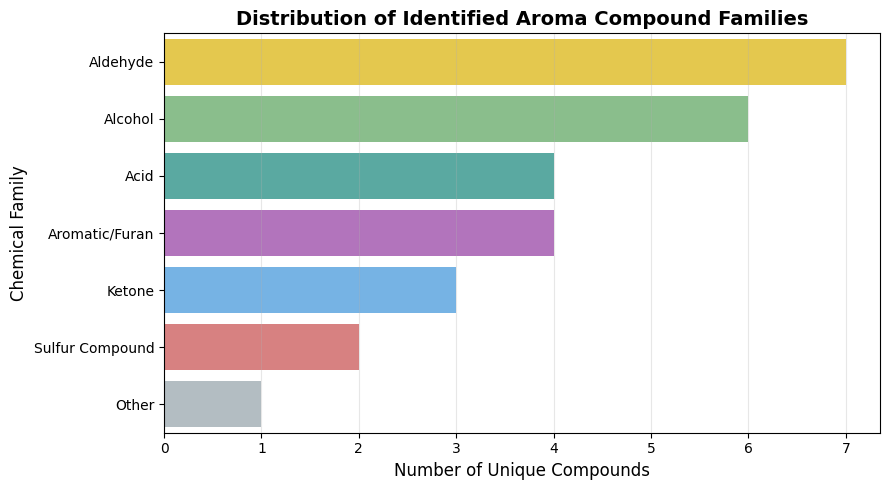

Chemical_Family
Aldehyde           7
Alcohol            6
Acid               4
Aromatic/Furan     4
Ketone             3
Sulfur Compound    2
Other              1
dtype: int64

In [0]:


# 1) wide -> long
id_col = aroma_matrix.index.name or "Variety"

aroma_long = (
    aroma_matrix
    .reset_index()
    .melt(
        id_vars=[id_col],
        var_name="Compound Name",
        value_name="Intensity"
    )
    .rename(columns={id_col: "Variety"})
)

# 2) numeric cleanup
aroma_long["Intensity"] = (
    aroma_long["Intensity"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

aroma_long["Intensity"] = pd.to_numeric(aroma_long["Intensity"], errors="coerce")

# 3) filter
aroma_long = aroma_long.dropna(subset=["Intensity"])
aroma_long = aroma_long.loc[aroma_long["Intensity"] > 0].copy()

# 4) annotate (IMPORTANT: unpack!)
aroma_long, aroma_desc_map, chemical_family_map = (
    assign_aroma_descriptions_and_families(aroma_long)
)

# 5) plot
plot_aroma_family_distribution(aroma_long)


# Run PCA and clustering 

Explained variance (2 PCs): 52.43%
Optimal number of clusters (based on silhouette): 2


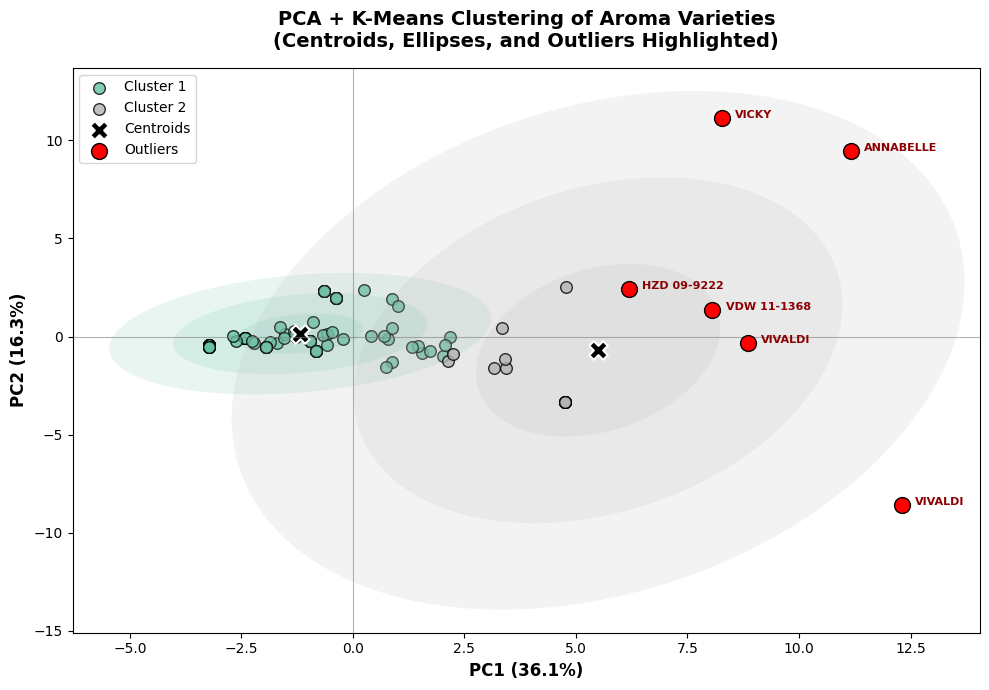


Results saved in: aroma_pca_kmeans


In [0]:

results, X_pca, clusters = cam.pca_kmeans_aroma(aroma_matrix)


In [0]:

# --- Run function ---
results, cluster_means, *_ = cam.analyze_aroma_clusters_gmm(aroma_matrix)

PCA components: 8 (90.1% variance)
Best k (BIC): 10

Clustering metrics:
 Silhouette: 0.446
 DB Index:   1.034
 CH Score:   44.1

Outliers (6): ['ANNABELLE', 'HZD 16-1081', 'VICKY', 'HZA 14-1447', 'COLOMBA', 'VIVALDI']

All results saved in: aroma_cluster_results


# Comparative Analysis of Aroma Compound Classes Between Outlier and Inlier Potato Varieties



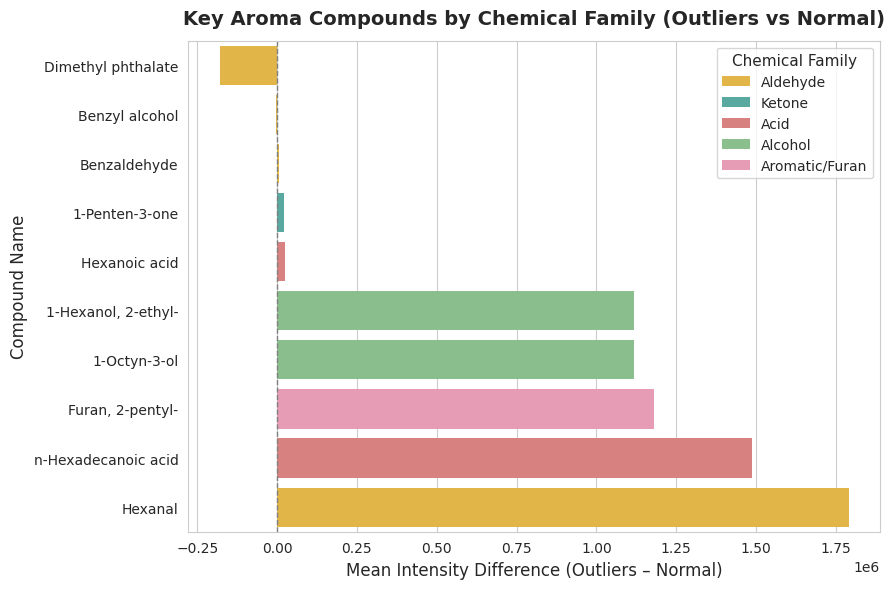

Saved: aroma_cluster_results/outlier_vs_normal_aromas.png


(group        Compound Name        Normal  ...        compound_norm  Chemical Family
 13      Dimethyl phthalate  2.873626e+05  ...   dimethyl phthalate         Aldehyde
 9           Benzyl alcohol  6.774328e+04  ...       benzyl alcohol         Aldehyde
 8             Benzaldehyde  6.904927e+03  ...         benzaldehyde         Aldehyde
 2           1-Penten-3-one  8.073978e+04  ...       1-penten-3-one           Ketone
 20           Hexanoic acid  6.694185e+04  ...        hexanoic acid             Acid
 0      1-Hexanol, 2-ethyl-  6.273474e+05  ...  1-hexanol, 2-ethyl-          Alcohol
 1             1-Octyn-3-ol  6.273474e+05  ...         1-octyn-3-ol          Alcohol
 18        Furan, 2-pentyl-  2.863915e+05  ...     furan, 2-pentyl-   Aromatic/Furan
 25     n-Hexadecanoic acid  1.720066e+06  ...  n-hexadecanoic acid             Acid
 19                 Hexanal  4.449635e+05  ...              hexanal         Aldehyde
 
 [10 rows x 6 columns],
 group                Compound Name  ..

In [0]:

outliers = results.loc[results["is_outlier"], "Variety"].tolist()
cam.plot_outlier_vs_normal_aromas(aroma_matrix, outliers, chemical_family_map=chemical_family_map)

In [0]:
# =========================================================
# CONVERT aroma_matrix → aroma_sample_df
# =========================================================
# safety copy
aroma_sample_df = aroma_matrix.copy()

# ensure Variety is a column (not index)
if aroma_sample_df.index.name == "Variety":
    aroma_sample_df = aroma_sample_df.reset_index()

# basic sanity checks
assert "Variety" in aroma_sample_df.columns, "Variety column missing"



#  Major Contributing Aroma Compounds (Mean Intensity-Based Ranking)


 Total compounds analyzed: 26
 Top 10 aroma compounds by average intensity:

                               mean         std
Compound Name                                  
n-Hexadecanoic acid      1832469.46  1188873.80
2,3-Butanedione           752004.80   311867.05
1-Octyn-3-ol              711889.20   921557.72
1-Hexanol, 2-ethyl-       711889.20   921557.72
Eucalyptol                711889.20   921557.72
Hexanal                   580315.88  1039423.12
Dimethyl disulfide        524792.00   441512.66
Furan, 2-pentyl-          375766.89   836605.76
2-methoxy-Phenol          350817.18   139219.01
2-Propanone, 1-methoxy-   350817.18   139219.01


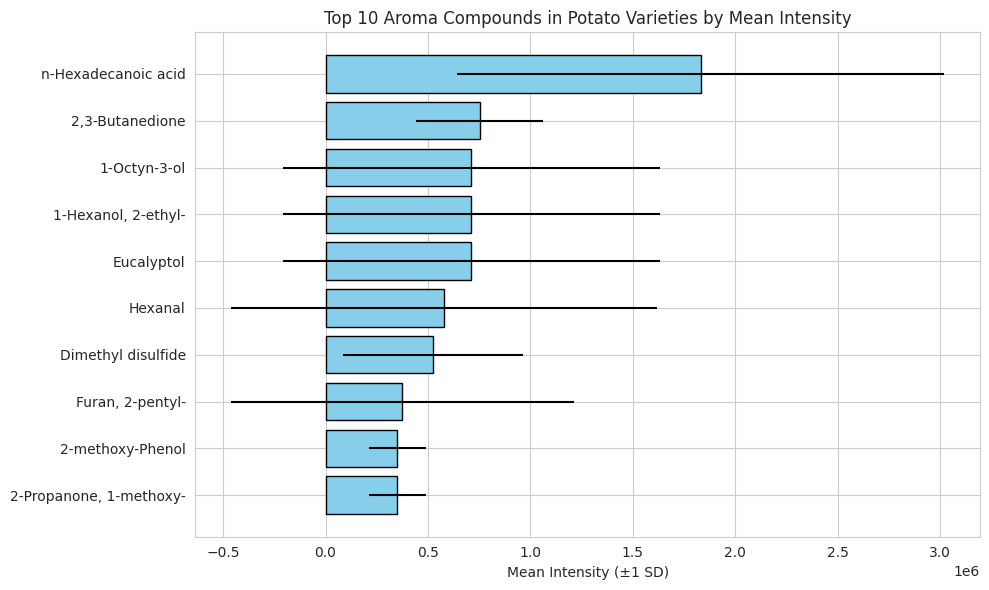

In [0]:
desc_stats, top_compounds = cam.summarize_aroma_intensities(aroma_sample_df, top_n=10)

# Heatmap of Top Aroma Compounds in Potato Varieties


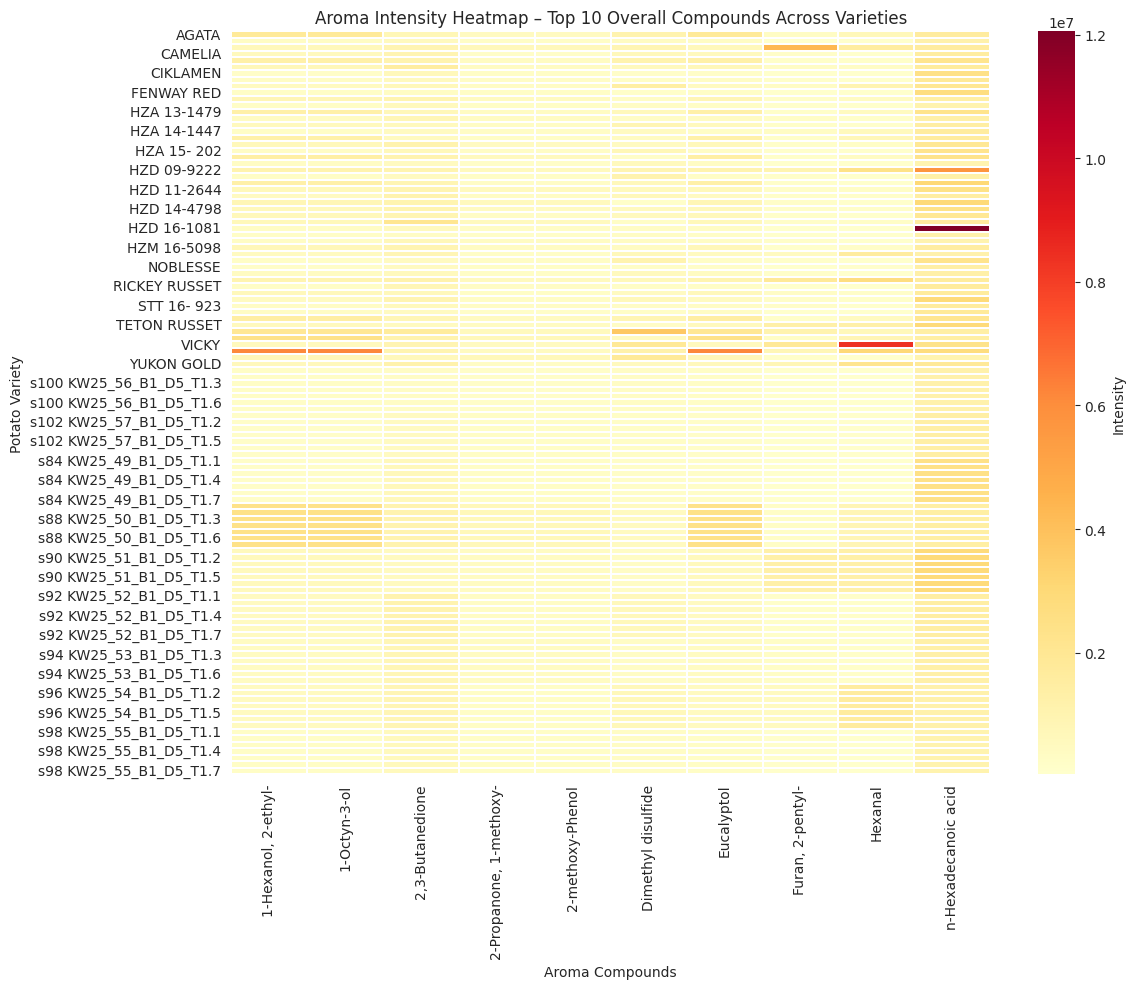

Compound,"1-Hexanol, 2-ethyl-",1-Octyn-3-ol,"2,3-Butanedione","2-Propanone, 1-methoxy-",2-methoxy-Phenol,Dimethyl disulfide,Eucalyptol,"Furan, 2-pentyl-",Hexanal,n-Hexadecanoic acid
Variety,,,,,,,,,,
AGATA,1776171.0,1776171.0,747553.0,437221.0,437221.0,1025447.0,1776171.0,344854.0,684160.0,1630007.0
ALVERSTONE R.,340051.0,340051.0,539526.0,261639.0,261639.0,393405.0,340051.0,55503.0,71656.0,1175280.0
ANNABELLE,606038.0,606038.0,942426.0,625377.0,625377.0,912376.0,606038.0,4315922.5,1574564.0,1609763.0
CAMELIA,590881.0,590881.0,954637.0,212451.0,212451.0,638243.0,590881.0,224822.0,79232.0,1577020.0
CARIBOU RUSSET,1286042.0,1286042.0,1055387.0,371695.0,371695.0,1103605.0,1286042.0,173041.0,176904.0,2179402.0
...,...,...,...,...,...,...,...,...,...,...
s98 KW25_55_B1_D5_T1.3,240823.0,240823.0,574808.0,260203.0,260203.0,312319.0,240823.0,101023.0,56179.0,1089057.0
s98 KW25_55_B1_D5_T1.4,240823.0,240823.0,574808.0,260203.0,260203.0,312319.0,240823.0,101023.0,56179.0,1089057.0
s98 KW25_55_B1_D5_T1.5,240823.0,240823.0,574808.0,260203.0,260203.0,312319.0,240823.0,101023.0,56179.0,1089057.0


In [0]:
# Show top 10 compounds overall across varieties
cam.plot_top_aroma_heatmap(aroma_sample_df, top_n=10, mode="overall")

# Feature Importance Analysis of Aroma Compounds Using PCA Loadings 

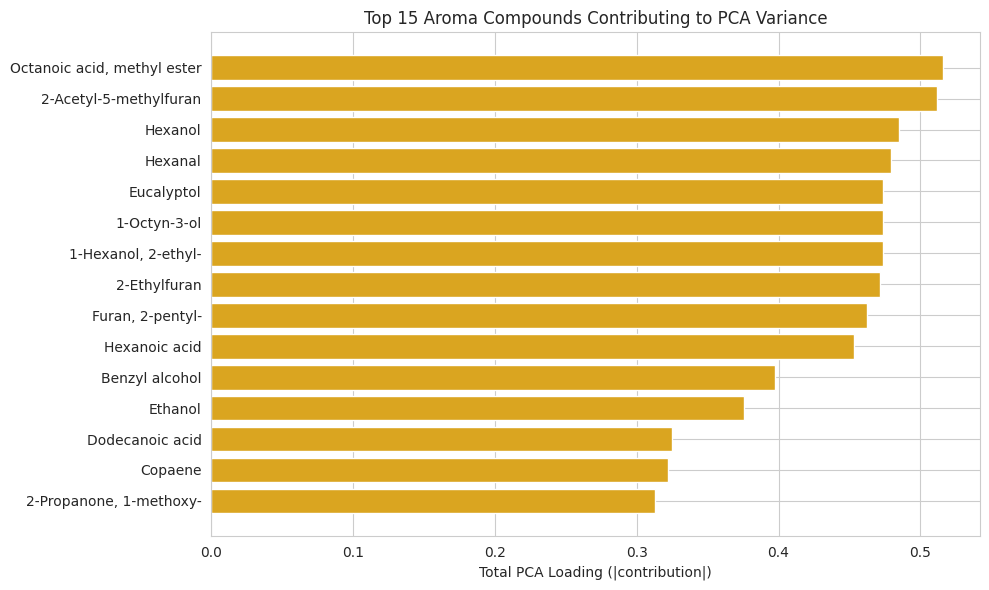

 Top 15 most contributing compounds:
                                  PC1       PC2  Total_Importance
Compound Name                                                    
Octanoic acid, methyl ester  0.246872  0.269424          0.516296
2-Acetyl-5-methylfuran       0.145526  0.366468          0.511994
Hexanol                      0.145245  0.340074          0.485319
Hexanal                      0.190941  0.288359          0.479300
Eucalyptol                   0.256204  0.217493          0.473698
1-Octyn-3-ol                 0.256204  0.217493          0.473698
1-Hexanol, 2-ethyl-          0.256204  0.217493          0.473698
2-Ethylfuran                 0.156678  0.315148          0.471826
Furan, 2-pentyl-             0.156476  0.305598          0.462074
Hexanoic acid                0.260835  0.192095          0.452930
Benzyl alcohol               0.203718  0.193544          0.397262
Ethanol                      0.243604  0.131872          0.375476
Dodecanoic acid              0.137537  

In [0]:
importance_df = cam.compute_feature_importance_from_pca(aroma_sample_df)


# Joining the sensory panel data 


In [0]:
!pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:

# --- Read the sensory Excel file using config path ---
sensory_path = config["paths"]["sensory_data"]
sensory = pd.read_excel(sensory_path)

# --- Print column names and preview the first few rows ---
print("Columns:", list(sensory.columns))
display(sensory.head(config["settings"]["display_rows"]))


Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, clus

VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,Visible Ring,Patches/ Blemishes,Waxy/ Shine,Floury/Flaky,Intensity of Aroma,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Intensity of Flavour,Potato Starch,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Acidic,Dry Mouthfeel,Waxy -Flesh,Mushy -Flesh,Crumbly - Flesh,Sticky - Flesh,Soft - Flesh,Chewy - Skin,Thickness - Skin,Starchy Aftertaste,Bitter Aftertaste,Drying Aftertaste,Sour Aftertaste,Sweet Aftertaste,Metalic,Unnamed: 47,"cluster 1 Sp, cluster 3 UK","cluster 2 Sp, cluster 1 UK","cluster 3 Sp, cluster 2 UK","cluster 1 Sp, cluster 3 UK.1","cluster 2 Sp, cluster 1 UK.1","cluster 3 Sp, cluster 2 UK.1",Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,13.333,5.521,24.146,10.583,40.843,18.537,15.953,4.385,21.588,19.845,3.491,29.071,40.979,28.018,17.627,15.329,26.573,10.678,24.014,3.098,17.36,12.52,11.959,36.073,21.58,19.601,15.917,28.364,40.155,30.056,24.854,24.316,15.647,34.603,14.179,1.79,16.498,null,5.1663698,5.689059207999998,5.003401500000001,49.92147255445099,80.60709936506272,88.84804953072177,null,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.13367281985997,471.3
AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,15.167,3.708,28.771,11.667,41.191,16.906,13.953,5.537,21.11,18.888,3.578,31.049,42.109,30.952,10.171,11.633,18.378,7.548,30.34,3.25,10.6,10.672,10.372,35.899,8.733,29.514,15.178,24.712,56.329,23.664,21.441,27.272,10.255,29.06,8.114,2.377,6.802,null,7.062588400000001,6.000016903999999,5.631414000000001,68.24420756214238,85.01299443195812,100.0,null,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.22770058269833,892.4
AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,25.792,10.917,16.937,28.667,38.691,23.58,12.801,3.298,23.219,15.823,1.752,26.592,35.348,35.3,8.018,5.872,20.421,3.787,29.188,1.859,13.447,8.803,4.959,52.508,5.211,15.057,30.069,24.342,47.22,24.012,19.158,31.163,8.777,43.712,4.071,1.203,9.28,null,3.1528587999999997,6.087160967999999,4.4545785,30.465367394385762,86.24772059125799,79.1023089405254,null,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891752577319586,77.6
AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,23.542,6.104,20.333,23.313,40.234,18.276,16.649,4.755,18.567,15.214,3.426,30.462,41.457,28.778,11.192,12.155,20.334,7.135,33.122,2.729,17.447,10.085,6.894,31.138,9.559,27.122,7.7,27.451,56.612,20.903,18.158,25.816,9.038,25.712,8.071,1.681,8.78,null,8.455572800000002,5.608341447999998,5.251437000000001,81.70430337126902,79.46342617359797,93.25254722881323,null,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.93868122637548,238.1
AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,8.5,2.417,29.354,9.375,38.017,19.319,11.605,4.407,18.132,18.584,3.209,30.94,39.022,27.518,13.018,11.176,20.486,11.591,24.644,3.511,15.991,9.846,8.959,33.551,20.167,18.101,13.265,25.842,41.133,20.882,18.245,23.055,11.016,26.625,9.331,3.007,8.107,null,7.631835600000002,6.376880296,4.8261330000000005,73.74471557291199,90.35269362919641,85.70019891984498,null,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.51122375090515,414.3


# Sensory Panel Data Processing

In [0]:

sensory_path = config["paths"]["sensory_data"]

sensory = pd.read_excel(sensory_path, sheet_name=0, engine="openpyxl")  # sheet_name can be name too
print("Shape:", sensory.shape)
print("Columns:", list(sensory.columns))
display(sensory.head(config["settings"]["display_rows"]))


Shape: (63, 64)
Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cl

VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,Visible Ring,Patches/ Blemishes,Waxy/ Shine,Floury/Flaky,Intensity of Aroma,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Intensity of Flavour,Potato Starch,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Acidic,Dry Mouthfeel,Waxy -Flesh,Mushy -Flesh,Crumbly - Flesh,Sticky - Flesh,Soft - Flesh,Chewy - Skin,Thickness - Skin,Starchy Aftertaste,Bitter Aftertaste,Drying Aftertaste,Sour Aftertaste,Sweet Aftertaste,Metalic,Unnamed: 47,"cluster 1 Sp, cluster 3 UK","cluster 2 Sp, cluster 1 UK","cluster 3 Sp, cluster 2 UK","cluster 1 Sp, cluster 3 UK.1","cluster 2 Sp, cluster 1 UK.1","cluster 3 Sp, cluster 2 UK.1",Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,13.333,5.521,24.146,10.583,40.843,18.537,15.953,4.385,21.588,19.845,3.491,29.071,40.979,28.018,17.627,15.329,26.573,10.678,24.014,3.098,17.36,12.52,11.959,36.073,21.58,19.601,15.917,28.364,40.155,30.056,24.854,24.316,15.647,34.603,14.179,1.79,16.498,null,5.1663698,5.689059207999998,5.003401500000001,49.92147255445099,80.60709936506272,88.84804953072177,null,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.13367281985997,471.3
AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,15.167,3.708,28.771,11.667,41.191,16.906,13.953,5.537,21.11,18.888,3.578,31.049,42.109,30.952,10.171,11.633,18.378,7.548,30.34,3.25,10.6,10.672,10.372,35.899,8.733,29.514,15.178,24.712,56.329,23.664,21.441,27.272,10.255,29.06,8.114,2.377,6.802,null,7.062588400000001,6.000016903999999,5.631414000000001,68.24420756214238,85.01299443195812,100.0,null,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.22770058269833,892.4
AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,25.792,10.917,16.937,28.667,38.691,23.58,12.801,3.298,23.219,15.823,1.752,26.592,35.348,35.3,8.018,5.872,20.421,3.787,29.188,1.859,13.447,8.803,4.959,52.508,5.211,15.057,30.069,24.342,47.22,24.012,19.158,31.163,8.777,43.712,4.071,1.203,9.28,null,3.1528587999999997,6.087160967999999,4.4545785,30.465367394385762,86.24772059125799,79.1023089405254,null,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891752577319586,77.6
AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,23.542,6.104,20.333,23.313,40.234,18.276,16.649,4.755,18.567,15.214,3.426,30.462,41.457,28.778,11.192,12.155,20.334,7.135,33.122,2.729,17.447,10.085,6.894,31.138,9.559,27.122,7.7,27.451,56.612,20.903,18.158,25.816,9.038,25.712,8.071,1.681,8.78,null,8.455572800000002,5.608341447999998,5.251437000000001,81.70430337126902,79.46342617359797,93.25254722881323,null,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.93868122637548,238.1
AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,8.5,2.417,29.354,9.375,38.017,19.319,11.605,4.407,18.132,18.584,3.209,30.94,39.022,27.518,13.018,11.176,20.486,11.591,24.644,3.511,15.991,9.846,8.959,33.551,20.167,18.101,13.265,25.842,41.133,20.882,18.245,23.055,11.016,26.625,9.331,3.007,8.107,null,7.631835600000002,6.376880296,4.8261330000000005,73.74471557291199,90.35269362919641,85.70019891984498,null,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.51122375090515,414.3


In [0]:

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = cam.summarize_sensory_traits(sensory, sensory_cols)

 Rows (unique varieties): 59
 Traits averaged: 20

 Example of summarized sensory data:
  VARIETY  Metallic Flavour  Bitter Flavour  ...   Fresh  Potato Starch  Metalic
0   ADORA            17.627          15.329  ...  29.071         28.018   16.498
1   AGATA            10.171          11.633  ...  31.049         30.952    6.802
2   AGRIA             8.018           5.872  ...  26.592         35.300    9.280
3   AMBRA            11.192          12.155  ...  30.462         28.778    8.780
4  AMPERA            13.018          11.176  ...  30.940         27.518    8.107

[5 rows x 21 columns]


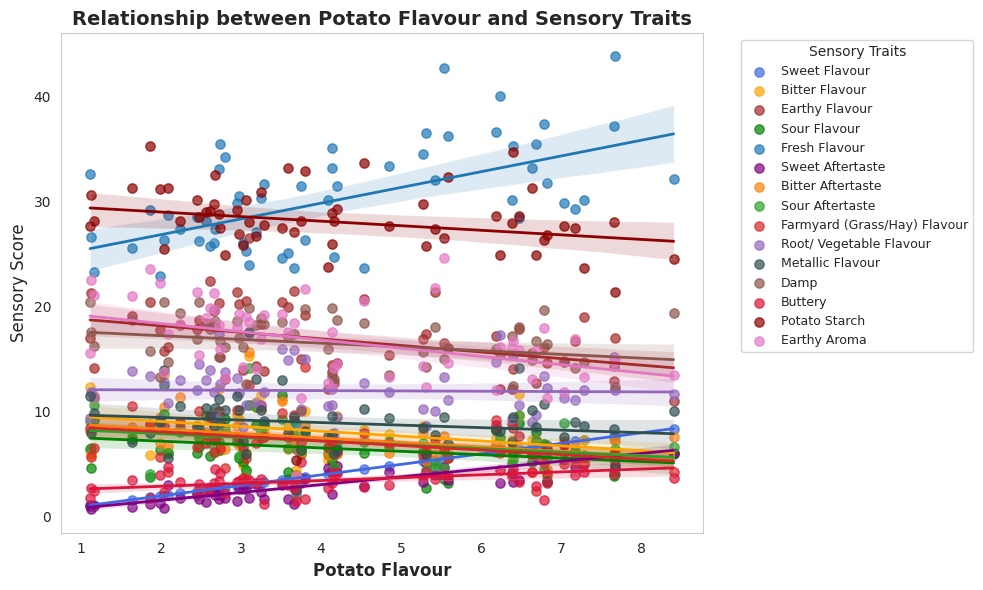

In [0]:

cam.plot_sensory_vs_flavour(sensory_summary, base_trait="SWEET FLAVOUR")


# Predicting the flavors for all the non existing varaieties by using the aroma compounds

In [0]:

merged_aroma_sensory, common = cam.merge_aroma_with_sensory(aroma_sample_df, sensory_summary)


Varieties in Aroma Data   : 115
Varieties in Sensory Data : 59
Common varieties          : 5
Merged varieties          : 5
Merged shape              : (8, 47)


,Variety,"1-Hexanol, 2-ethyl-",1-Octyn-3-ol,1-Penten-3-one,"2,3-Butanedione",2-Acetyl-5-methylfuran,2-Ethylfuran,"2-Propanone, 1-methoxy-",2-methoxy-Phenol,Benzaldehyde,Benzyl alcohol,"Butanal, 3-methyl-",Copaene,Dimethyl disulfide,Dimethyl phthalate,Dimethyl trisulfide,Dodecanoic acid,Ethanol,Eucalyptol,"Furan, 2-pentyl-",Hexanal,Hexanoic acid,Hexanol,Nonanal,"Octanoic acid, methyl ester",Phenol,n-Hexadecanoic acid,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Bitter Aftertaste,Sour Aftertaste,Sweet Aftertaste,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Potato Starch,Metalic
0,CHALLENGER,903445.0,903445.0,96548.0,1715423.0,11909.0,229030.0,544088.0,544088.0,10525.0,105551.0,21904.0,12680.0,485751.0,117931.0,34731.0,39606.0,72562.0,903445.0,231961.0,437536.0,103251.0,113695.0,154096.0,196162.0,196778.0,1628142.0,6.374,6.316,14.985,6.003,31.447,3.748,10.270,7.157,6.099,6.352,3.264,11.349,14.086,5.661,15.838,10.051,5.220,34.402,28.180,7.010
1,ANNABELLE,825025.0,825025.0,82106.0,1223480.0,306334.0,6092240.0,911303.0,911303.0,9410.0,209523.0,234936.0,62419.0,788400.0,79902.0,144653.0,39442.0,136625.0,825025.0,8399416.0,3075456.0,179867.0,869654.0,200168.0,242299.0,226760.0,907472.0,8.149,7.568,12.182,6.504,40.035,6.229,17.317,6.042,6.951,7.527,3.203,16.124,13.910,4.341,16.545,15.475,4.426,40.744,24.909,7.389
2,VIVALDI,7098053.0,7098053.0,92249.0,984631.0,12275.0,115059.0,469118.0,469118.0,16727.0,81188.0,68184.0,16182.0,886778.0,423779.0,199659.0,1142776.0,153783.0,7098053.0,290191.0,1230064.0,226467.0,136055.0,222120.0,1746605.0,191956.0,4001803.0,7.641,6.196,14.781,6.953,29.879,7.040,11.297,5.021,7.185,8.943,5.378,11.911,11.344,5.623,16.882,14.875,6.838,30.883,27.663,6.227
3,ANNABELLE,387051.0,387051.0,83176.0,661372.0,13878.0,97857.0,339451.0,339451.0,33317.0,19503.0,15783.0,55008.0,1036352.0,42821.0,40096.0,25135.0,54890.0,387051.0,232429.0,73672.0,32632.0,49566.0,91376.0,86888.0,85824.0,2312054.0,8.149,7.568,12.182,6.504,40.035,6.229,17.317,6.042,6.951,7.527,3.203,16.124,13.910,4.341,16.545,15.475,4.426,40.744,24.909,7.389
4,RUSSET BURBANK,631449.0,631449.0,73174.0,647195.0,12935.0,137442.0,271351.0,271351.0,8562.0,12832.0,104603.0,485582.0,427327.0,2111892.0,36818.0,44167.0,80953.0,631449.0,317846.0,214680.0,58371.0,41752.0,198728.0,115750.0,123462.0,1644768.0,10.248,8.250,20.700,6.095,23.720,4.537,12.731,8.017,7.432,7.094,2.975,20.519,13.458,3.315,17.358,18.480,2.855,29.025,33.708,7.086


Found 26 aroma compounds and 20 sensory traits.
Displaying 26 compounds (threshold=0.2).


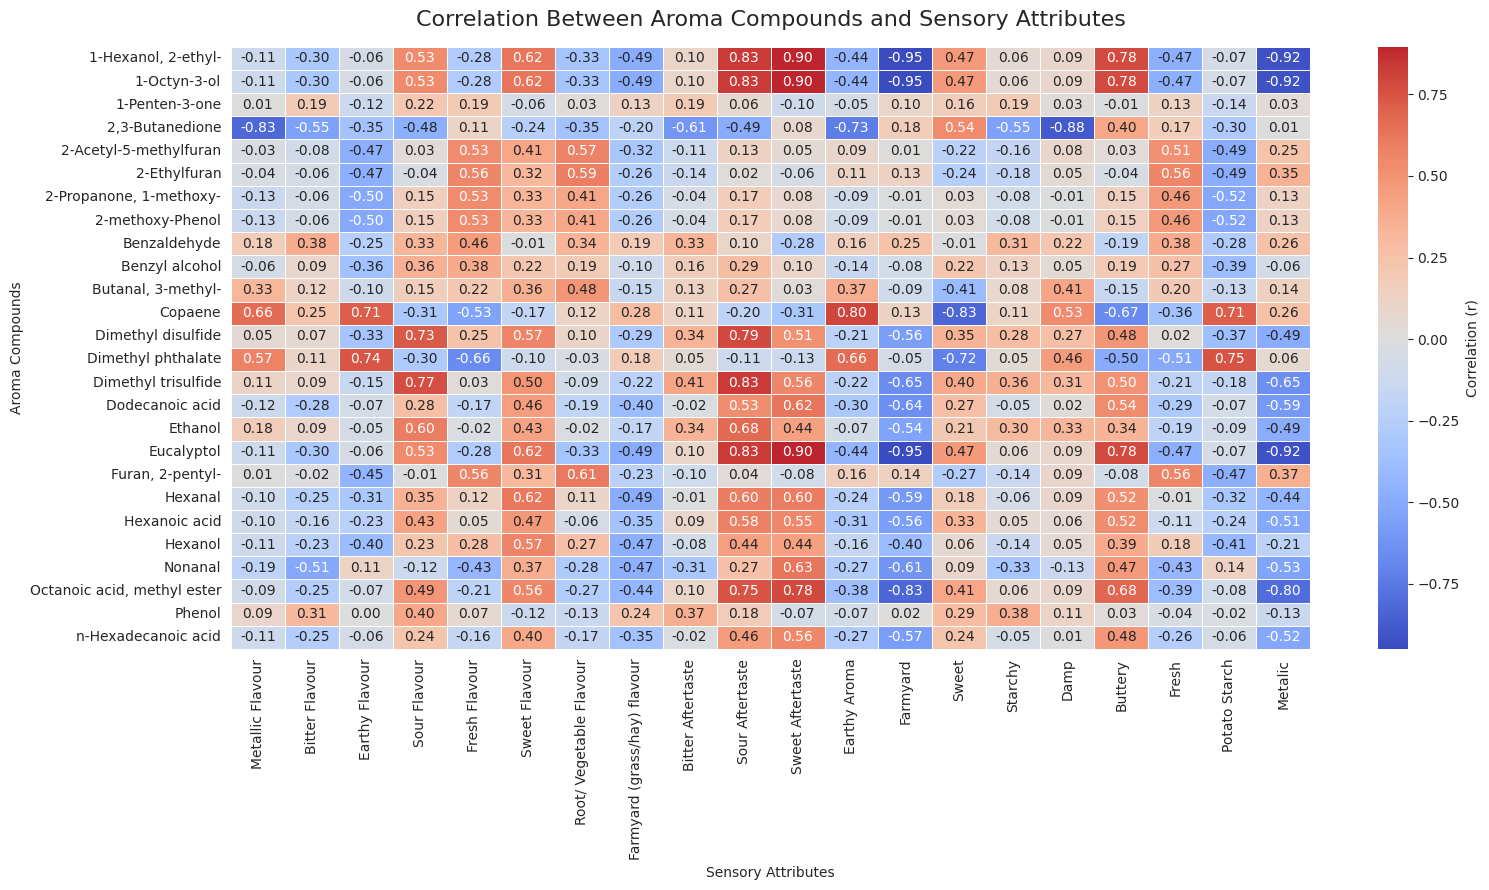

Correlation matrix saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american/aroma_sensory_corr_output.csv


In [0]:

# --- Define sensory columns 
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

corr_result = cam.plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    aroma_descriptions=None,  
    threshold=config["settings"]["correlation_threshold"],
    min_compounds=config["settings"]["min_compounds"],
    save_path=config["paths"]["aroma_sensory_corr_output_american"]
)

